<a href="https://colab.research.google.com/github/K1taK1ta/deep-learning-notebooks/blob/main/walker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bipedal Walker Control using DDPG

[Here, Task Description](https://imcs.dvfu.ru/cats/static/problem_text-cpid-6659301.html?sid=EMPidyH5FdmtYKqx5j8NlWTtw9aUYi)

# Imports

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 50.7 MB/s eta 0:00:00


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

In [ ]:
import numpy as np
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt
import torch

In [ ]:
import keras
print(keras.backend.backend())

torch


# Environment

In [ ]:
import gymnasium as gym

env = gym.make("BipedalWalker-v3", hardcore=False)

print(f"Пространство наблюдений: {env.observation_space}")
print(f"Пространство действий: {env.action_space}")
print(f"Размерность состояния: {env.observation_space.shape[0]}")
print(f"Размерность действия: {env.action_space.shape[0]}")
print(f"Диапазон действий: [{env.action_space.low[0]}, {env.action_space.high[0]}]")

obs, _ = env.reset()
print(f"\nПример наблюдения (shape={obs.shape}):\n{obs}")

Пространство наблюдений: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Пространство действий: Box(-1.0, 1.0, (4,), float32)
Размерность состояния: 24
Размерность действия: 4
Диапазон действий: [-1.0, 1.0]

Пример наблюдения (shape=(24,)):
[ 2.7471837e-03  2.3872508e-06 -3.1130126e-04 -1.6000014e-02
  9.2227206e-02  7.2267704e-04  8.6007589e-01  8.2864217e-04
  1.0000000e+00  3.2612596e-02  7.2263455e-04  8.5366863e-01
 -4.9173337e-04  1.0000000e+00  4.4081384e-01  4.4581994e-01
  4.6142259e-01  4.8954999e-01  5.3410256e-01  6.024608

# Replay Buffer

In [ ]:
class ReplayBuffer:

    def __init__(
        self,
        max_size: int,
        observation_space: gym.spaces.Space,
        action_space: gym.spaces.Space,
        seed: int | None = None
        ):

        """Stores the replay history with a maximum of `max_size` entries, removing old entries as needed.

        Parameters:
            max_size: maximal number of entries to keep
            observation_space: specification of the observation space
            action_space: specification of the action space
            seed: seed to initialize the internal random number generator for reproducibility"""

        self.max_size = max_size # Максимальный размер буффера, это память агента
        self.current_size = 0   # счётчик реального количества данных
        self.current_index = 0  # указатель на место следующей записи

        self.observation_space = observation_space # Какие действия может показывать игра, здесь хранятся параметры картинки из Atari # Box(0, 255, (4, 210, 160, 3), uint8)
        self.action_space = action_space # Какие действия можем выдавать # Пространство действий: MultiDiscrete([4 4 4 4])

        self.current_observations = np.empty((max_size, *observation_space.shape), dtype=observation_space.dtype)
        self.next_observations = np.empty((max_size, *observation_space.shape), dtype=observation_space.dtype)

        self.actions = np.empty((max_size, *action_space.shape), dtype=np.float32)
        self.rewards = np.empty((max_size,), dtype=np.float32)
        self.dones = np.empty((max_size,), dtype=bool)

        self.rng = np.random.default_rng(seed)

    def add(self, current_observation, action, reward, next_observation, done):
        index = self.current_index
        self.current_observations[index] = current_observation
        self.actions[index] = action
        self.rewards[index] = reward
        self.next_observations[index] = next_observation
        self.dones[index] = done

        self.current_index = (index + 1) % self.max_size
        # index: 0 → 1 → 2 → 3 → 4 → 0 → 1 → ...
        self.current_size = min(self.max_size, self.current_size + 1)

    def sample(self, n_samples: int, replace: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Randomly samples `n_samples` from the buffer.

        Parameters:
            n_samples: number of samples to select
            replace: sample with or without replacement

        Returns:
            current observations, actions, rewards, next observations, done"""

        # Параметр replace в методе rng.choice (или np.random.choice) определяет, может ли один и тот же элемент из буфера попасть в одну выборку (батч) несколько раз.
        sample_indices = self.rng.choice(self.current_size, size=n_samples, replace=replace)
        return self[sample_indices] #  # вызывает __getitem__

    def clear(self) -> None:
        """Clears the buffer"""
        self.current_index = 0
        self.current_size = 0

    def __getitem__(self, index: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Gets a sample at `index`

        Parameters:
            index: index of the sample to get

        Returns:
            current observation, action, reward, next observation, done"""
        return (
            self.current_observations[index],
            self.actions[index],
            self.rewards[index],
            self.next_observations[index],
            self.dones[index]
        )


    def __len__(self) -> int:
        """Returns the number of entries in the buffer"""
        return self.current_size

# Model

In [ ]:
import keras
from keras import layers, ops

# Заводим отдельную сеть — Actor (policy) μ_θ, которая сама предсказывает лучшее действие
def get_actor(state_dim, action_dim, hidden1=256, hidden2=256):
    state_input = layers.Input(shape=(state_dim,))
    x = layers.Dense(hidden1, activation="relu")(state_input)
    x = layers.Dense(hidden2, activation="relu")(x)
    output = layers.Dense(action_dim, activation="tanh")(x)
    return keras.Model(inputs=state_input, outputs=output, name="actor")


def get_critic(state_dim, action_dim, hidden1=256, hidden2=256):
    state_input = layers.Input(shape=(state_dim,))
    action_input = layers.Input(shape=(action_dim,))
    x = layers.Concatenate()([state_input, action_input])
    x = layers.Dense(hidden1, activation="relu")(x)
    x = layers.Dense(hidden2, activation="relu")(x)
    output = layers.Dense(1)(x)
    return keras.Model(inputs=[state_input, action_input], outputs=output, name="critic")


# Loss

In [ ]:
def ddpg_loss(
    current_observation: keras.KerasTensor,
    action: keras.KerasTensor,
    reward: keras.KerasTensor,
    next_observation: keras.KerasTensor,
    done: keras.KerasTensor,
    q_model: keras.Model,
    policy_model: keras.Model,
    target_q_model: keras.Model,
    target_policy_model: keras.Model,
    gamma: float
) -> tuple[keras.KerasTensor, keras.KerasTensor]:

    # --- Critic loss ---
    # Critic loss:  L = mean((Q(s,a) - y)²) ← учим Q предсказывать reward

    # y = r + γ * (1 - d) * Q_targ(s', μ_targ(s'))

    # Берём следующее состояние s' и вычисляем действие по target policy
    # Это то, как DDPG обходит проблему max_a Q(s',a) в непрерывных действиях
    next_action = target_policy_model(next_observation) # μ_targ(s')

    # target_q_model — это target Critic
    # Берём s' и действие, предложенное target Actor, и получаем ценность будущего состояния
    # Именно этот Q используется как стабильная цель для обучения основной Q
    target_q = target_q_model([next_observation, next_action]) # # Q_targ(s', μ_targ(s'))

    #  Это формула target для Critic, как в уравнении Беллмана.
    y = reward + gamma * (1 - done) * target_q

    # q_model — это основной Critic
    q = q_model([current_observation, action])

    # Идея: мы хотим, чтобы Critic «знал», сколько будущих наград можно получить, если следовать текущей (target) политике
    # Actor не может сам вычислить «какое действие лучше» в непрерывном пространстве действий
    # Critic оценивает Q(s,a) → Actor использует эту оценку, чтобы выбирать действия, которые максимизируют Q
    # То есть Critic — это оценщик качества действий, а Actor — исполнитель
    q_loss = ops.mean((q - ops.stop_gradient(y)) ** 2)

    # --- Actor loss ---
    # Actor loss:   L = -mean(Q(s, μ(s))) ← учим μ предлагать лучшее действие

    predicted_action = policy_model(current_observation)

    # policy_model - это актор
    # Он берёт текущее состояние s и предсказывает действие, которое, по его мнению, максимально выгодное
    # На данном этапе Actor ещё не знает точно, какое действие лучше — он учится на Critic

    # Critic возвращает оценку качества этого действия (сколько будущей награды оно принесёт)
    # Actor использует Critic как «судью»: Critic говорит, насколько хорошее действие Actor предлагает
    # Мы берём отрицание Q, потому что Actor хочет максимизировать Q
    # Минимизация -Q → максимизация Q
    # Усреднение по батчу (mean) → обучение стабильно
    policy_loss = -ops.mean(q_model([current_observation, predicted_action]))

    return q_loss, policy_loss

# Sampler

In [ ]:
# Exploration vs Exploitation (исследование vs использование)

# Проблема: политика детерминистическая — для одного состояния всегда выдаёт одно и то же действие
# В начале обучения actor выдаёт мусор, и если следовать ему — агент будет делать одно и то же бесполезное движение и ничему не научится
# Решение: при обучении добавляем шум к действиям

# Авторы DDPG предлагали OU noise (шум Орнштейна-Уленбека) — он коррелирован во времени, плавный
# Но ообычный гауссовский шум работает не хуже и проще

# При тестировании шум не добавляем — смотрим чистую политику
# Поэтому в evaluate и test_agent мы вызываем actor без sampler

class Sampler:
    def __init__(self, noise_std: float = 0.1, seed: int | None = None):
        self.noise_std = noise_std
        self.rng = np.random.default_rng(seed)

    def __call__(self, action: np.ndarray) -> np.ndarray:
        noise = self.rng.normal(0, self.noise_std, size=action.shape)
        # среднее = 0, стандартное отклонение = self.noise_std
        return np.clip(action + noise, -1.0, 1.0)
        # ограничивает действия в допустимом диапазоне [-1, 1]

# Play the game

In [ ]:
# def play_game(
#     model: keras.Model,
#     env: gym.Env,
#     steps: int = None,
#     sampler: Sampler = None,
#     buffer: ReplayBuffer = None,
#     record: bool = False,
#     one_episode: bool = False
# ):
#     """Универсальная функция для взаимодействия со средой.

#     - Обучение: play_game(actor, env, steps=1000, sampler=sampler, buffer=buffer)
#     - Evaluation: play_game(actor, eval_env, one_episode=True)
#     - Запись видео: play_game(actor, render_env, one_episode=True, record=True)
#     """

#     obs, _ = env.reset()
#     total_reward = 0
#     frames = []
#     step = 0

#     while True:
#         if record:
#             frames.append(env.render())

#         obs_input = np.expand_dims(obs, 0).astype(np.float32)
#         with torch.no_grad():
#             action = keras.ops.convert_to_numpy(model(obs_input))[0]

#         if sampler is not None:
#             action = sampler(action)

#         next_obs, reward, terminated, truncated, _ = env.step(action)
#         done = terminated or truncated
#         total_reward += reward

#         if buffer is not None:
#             buffer.add(obs, action, reward, next_obs, float(terminated))

#         obs = next_obs if not done else env.reset()[0]
#         if done:
#             total_reward_finished = total_reward
#             total_reward = 0
#             if one_episode:
#                 return total_reward_finished, frames

#         step += 1
#         if steps is not None and step >= steps:
#             break

#     return obs

# Training

In [ ]:
# --- Soft update ---

# Это мягкое обновление (soft update) target-сети
# Реализация Polyak averaging

# В DQN — жёстко копировали веса каждые N шагов. В DDPG — мягко (Polyak averaging) после каждого шага:
# ```
# φ_targ ← ρ * φ_targ + (1 - ρ) * φ
# ```
# ρ = 0.995 означает: «возьми 99.5% старых весов и 0.5% новых». Target сеть еле-еле двигается → стабильная цель для обучения.

def soft_update(target_model, source_model, polyak=0.995):
    for target_w, source_w in zip(target_model.variables, source_model.variables):
        target_w.assign(polyak * target_w + (1 - polyak) * source_w)
        # assign перезаписать значение переменной


In [ ]:
# --- Гиперпараметры ---
gamma = 0.99
polyak = 0.995
actor_lr = 1e-3
critic_lr = 1e-3
buffer_size = 1_000_000
batch_size = 128
noise_std = 0.1
start_steps = 10_000  # случайные действия в начале для exploration

# --- Среда ---
env = gym.make("BipedalWalker-v3", hardcore=False)
state_dim = env.observation_space.shape[0]   # 24
action_dim = env.action_space.shape[0]       # 4

# --- Модели ---
actor = get_actor(state_dim, action_dim)
critic = get_critic(state_dim, action_dim)
actor_target = get_actor(state_dim, action_dim)
critic_target = get_critic(state_dim, action_dim)

actor_target.set_weights(actor.get_weights())
critic_target.set_weights(critic.get_weights())

# --- Оптимизаторы ---
actor_optimizer = keras.optimizers.Adam(learning_rate=actor_lr)
critic_optimizer = keras.optimizers.Adam(learning_rate=critic_lr)

# --- Буфер и сэмплер ---
buffer = ReplayBuffer(buffer_size, env.observation_space, env.action_space, seed=42)
sampler = Sampler(noise_std=noise_std, seed=42)

# Вспомогательная функция — достаём torch-параметры из keras модели
def get_torch_params(model):
    return [v.value for v in model.trainable_variables]

In [ ]:
obs, _ = env.reset()
for _ in range(start_steps):
    action = env.action_space.sample()  # случайное действие
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    # terminated — эпизод закончился по правилам среды (робот упал)
    # truncated — эпизод обрезан по лимиту шагов (время вышло, но робот ещё стоит)
    buffer.add(obs, action, reward, next_obs, done)

    if done:
        obs, _ = env.reset()
    else:
        obs = next_obs

print(f"Буфер заполнен: {len(buffer)} переходов")

Буфер заполнен: 10000 переходов


In [ ]:
# from tqdm.notebook import tqdm

# device = actor.trainable_variables[0].value.device

# # --- Гиперпараметры ---
# total_steps = 400_000
# update_every = 50
# eval_freq = 10_000
# eval_episodes = 5
# max_ep_len = 1600

# # --- Evaluate ---
# def evaluate(actor, env, n_episodes):
#     rewards = []
#     for _ in range(n_episodes):
#         obs, _ = env.reset()
#         total_reward = 0
#         for _ in range(max_ep_len):
#             obs_input = np.expand_dims(obs, 0).astype(np.float32)
#             with torch.no_grad():
#                 action = keras.ops.convert_to_numpy(actor(obs_input))[0]
#             obs, r, term, trunc, _ = env.step(action)
#             total_reward += r
#             if term or trunc:
#                 break
#         rewards.append(total_reward)
#     return np.mean(rewards)

# # --- Training ---
# eval_env = gym.make("BipedalWalker-v3", hardcore=False)
# obs, _ = env.reset()
# train_losses = []
# eval_rewards = []

# pbar = tqdm(range(1, total_steps + 1), desc="Training")
# for step in pbar:
#     # Выбираем действие
#     obs_input = np.expand_dims(obs, 0).astype(np.float32)
#     with torch.no_grad():
#         action = keras.ops.convert_to_numpy(actor(obs_input))[0]
#     action = sampler(action)

#     # Шаг в среде
#     next_obs, reward, terminated, truncated, _ = env.step(action)
#     done = terminated or truncated
#     store_done = float(terminated)
#     buffer.add(obs, action, reward, next_obs, store_done)
#     obs = next_obs if not done else env.reset()[0]

#     # Обучение каждые update_every шагов
#     if step % update_every == 0:
#         for _ in range(update_every):
#             batch = buffer.sample(batch_size)
#             states, actions, rewards_b, next_states, dones_b = batch

#             # Конвертируем в torch тензоры на GPU
#             states = torch.tensor(states, dtype=torch.float32, device=device)
#             actions = torch.tensor(actions, dtype=torch.float32, device=device)
#             rewards_b = torch.tensor(rewards_b, dtype=torch.float32, device=device).unsqueeze(-1)
#             next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
#             dones_b = torch.tensor(dones_b, dtype=torch.float32, device=device).unsqueeze(-1)

#             q_loss, policy_loss = ddpg_loss(
#                 states, actions, rewards_b, next_states, dones_b,
#                 critic, actor, critic_target, actor_target, gamma
#             )


#             # Достаём чистые torch-параметры из Keras моделей
#             # .value извлекает torch.Tensor из Keras Variable
#             critic_params = get_torch_params(critic)
#             actor_params = get_torch_params(actor)

#             # Считаем градиенты обоих лоссов ДО обновления весов
#             # retain_graph=True — не удаляем вычислительный граф после critic,
#             # потому что policy_loss тоже использует critic
#             critic_grads = torch.autograd.grad(q_loss, critic_params, retain_graph=True)
#             actor_grads = torch.autograd.grad(policy_loss, actor_params)

#             # Обновляем веса: optimizer применяет градиенты к параметрам
#             # Critic учится лучше предсказывать Q-значения
#             critic_optimizer.apply(critic_grads, critic.trainable_variables)
#             # Actor учится предлагать действия с большим Q
#             actor_optimizer.apply(actor_grads, actor.trainable_variables)

#             # Soft update: target сети медленно догоняют основные
#             # θ_targ ← 0.995 * θ_targ + 0.005 * θ
#             soft_update(actor_target, actor, polyak)
#             soft_update(critic_target, critic, polyak)

#             # Сохраняем critic loss для мониторинга
#             train_losses.append(float(q_loss))

#     # Прогресс-бар
#     if step % 1000 == 0:
#         pbar.set_postfix({
#             "q_loss": f"{np.mean(train_losses[-100:]):.4f}" if train_losses else "—",
#             "reward": f"{eval_rewards[-1]:.1f}" if eval_rewards else "—"
#         })

#     # Evaluation
#     if step % eval_freq == 0:
#         avg_reward = evaluate(actor, eval_env, eval_episodes)
#         eval_rewards.append(avg_reward)
#         avg_loss = np.mean(train_losses[-1000:]) if train_losses else 0
#         print(f"Step {step:>7d} | q_loss={avg_loss:.4f} | eval_reward={avg_reward:.1f}")

Training:   0%|          | 0/400000 [00:00<?, ?it/s]

Step   10000 | q_loss=2.5770 | eval_reward=-105.3
Step   20000 | q_loss=1.7745 | eval_reward=-116.6
Step   30000 | q_loss=1.9259 | eval_reward=-241.7
Step   40000 | q_loss=2.7574 | eval_reward=-111.2
Step   50000 | q_loss=1.9188 | eval_reward=62.1
Step   60000 | q_loss=1.6677 | eval_reward=-79.0
Step   70000 | q_loss=1.7126 | eval_reward=-120.1
Step   80000 | q_loss=1.6858 | eval_reward=-133.2
Step   90000 | q_loss=1.5441 | eval_reward=-125.8
Step  100000 | q_loss=1.9439 | eval_reward=31.0


In [ ]:
from tqdm.notebook import tqdm

device = actor.trainable_variables[0].value.device

# --- Гиперпараметры ---
total_steps = 200_000
update_every = 50
eval_freq = 10_000
eval_episodes = 5
max_ep_len = 1600

# --- Evaluate ---
def evaluate(actor, env, n_episodes):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        total_reward = 0
        for _ in range(max_ep_len):
            obs_input = np.expand_dims(obs, 0).astype(np.float32)
            with torch.no_grad():
                action = keras.ops.convert_to_numpy(actor(obs_input))[0]
            obs, r, term, trunc, _ = env.step(action)
            total_reward += r
            if term or trunc:
                break
        rewards.append(total_reward)
    return np.mean(rewards)

# --- Training ---
eval_env = gym.make("BipedalWalker-v3", hardcore=False)
obs, _ = env.reset()
eval_rewards = []

train_q_losses = []
train_p_losses = []

pbar = tqdm(range(1, total_steps + 1), desc="Training")
for step in pbar:
    # Выбираем действие
    obs_input = np.expand_dims(obs, 0).astype(np.float32)
    with torch.no_grad():
        action = keras.ops.convert_to_numpy(actor(obs_input))[0]
    action = sampler(action)

    # Шаг в среде
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    store_done = float(terminated)
    buffer.add(obs, action, reward, next_obs, store_done)
    obs = next_obs if not done else env.reset()[0]

    # Обучение каждые update_every шагов
    if step % update_every == 0:
        for _ in range(update_every):
            batch = buffer.sample(batch_size)
            states, actions, rewards_b, next_states, dones_b = batch

            # Конвертируем в torch тензоры на GPU
            states = torch.tensor(states, dtype=torch.float32, device=device)
            actions = torch.tensor(actions, dtype=torch.float32, device=device)
            rewards_b = torch.tensor(rewards_b, dtype=torch.float32, device=device).unsqueeze(-1)
            next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
            dones_b = torch.tensor(dones_b, dtype=torch.float32, device=device).unsqueeze(-1)

            q_loss, policy_loss = ddpg_loss(
                states, actions, rewards_b, next_states, dones_b,
                critic, actor, critic_target, actor_target, gamma
            )


            # Достаём чистые torch-параметры из Keras моделей
            # .value извлекает torch.Tensor из Keras Variable
            critic_params = get_torch_params(critic)
            actor_params = get_torch_params(actor)

            # Считаем градиенты обоих лоссов ДО обновления весов
            # retain_graph=True — не удаляем вычислительный граф после critic,
            # потому что policy_loss тоже использует critic
            critic_grads = torch.autograd.grad(q_loss, critic_params, retain_graph=True)
            actor_grads = torch.autograd.grad(policy_loss, actor_params)

            # Обновляем веса: optimizer применяет градиенты к параметрам
            # Critic учится лучше предсказывать Q-значения
            critic_optimizer.apply(critic_grads, critic.trainable_variables)
            # Actor учится предлагать действия с большим Q
            actor_optimizer.apply(actor_grads, actor.trainable_variables)

            # Soft update: target сети медленно догоняют основные
            # θ_targ ← 0.995 * θ_targ + 0.005 * θ
            soft_update(actor_target, actor, polyak)
            soft_update(critic_target, critic, polyak)

            # Сохраняем critic loss для мониторинга
            train_q_losses.append(float(q_loss.detach()))
            train_p_losses.append(float(policy_loss.detach()))


    if step % 1000 == 0:
        pbar.set_postfix({
            "q_loss": f"{np.mean(train_q_losses[-100:]):.4f}" if train_q_losses else "—",
            "p_loss": f"{np.mean(train_p_losses[-100:]):.4f}" if train_p_losses else "—",
            # "reward": f"{eval_rewards[-1]:.1f}" if eval_rewards else "—"
        })

    if step % eval_freq == 0:
        avg_reward = evaluate(actor, eval_env, eval_episodes)
        eval_rewards.append(avg_reward)
        avg_q = np.mean(train_q_losses[-1000:]) if train_q_losses else 0
        avg_p = np.mean(train_p_losses[-1000:]) if train_p_losses else 0
        print(f"Step {step:>7d} | q_loss={avg_q:.4f} | p_loss={avg_p:.4f} | eval_reward={avg_reward:.1f}")

Training:   0%|          | 0/200000 [00:00<?, ?it/s]

Step   10000 | q_loss=1.3954 | p_loss=-9.2050 | eval_reward=-108.6
Step   20000 | q_loss=1.7360 | p_loss=-20.3171 | eval_reward=-125.9
Step   30000 | q_loss=2.4865 | p_loss=-28.0134 | eval_reward=-116.9
Step   40000 | q_loss=2.2733 | p_loss=-35.6269 | eval_reward=-106.1
Step   50000 | q_loss=2.5998 | p_loss=-41.8530 | eval_reward=-28.0
Step   60000 | q_loss=2.3595 | p_loss=-43.4271 | eval_reward=-115.6
Step   70000 | q_loss=2.0652 | p_loss=-41.0216 | eval_reward=-20.0
Step   80000 | q_loss=2.2702 | p_loss=-38.2633 | eval_reward=-71.4
Step   90000 | q_loss=2.1757 | p_loss=-36.3629 | eval_reward=-106.6
Step  100000 | q_loss=2.1288 | p_loss=-34.2337 | eval_reward=-128.9
Step  110000 | q_loss=2.3374 | p_loss=-34.0396 | eval_reward=170.7
Step  120000 | q_loss=2.6652 | p_loss=-34.6292 | eval_reward=-113.6
Step  130000 | q_loss=3.4283 | p_loss=-39.8162 | eval_reward=-91.9
Step  140000 | q_loss=3.1719 | p_loss=-41.0988 | eval_reward=-166.3
Step  150000 | q_loss=3.3167 | p_loss=-40.5158 | eval_

policy_loss = -mean(Q(s, μ(s))). Если Q растёт → loss уходит в минус → actor предлагает всё более ценные действия.

In [ ]:
# @title
pbar = tqdm(range(1, total_steps + 1), desc="Training")
for step in pbar:
    # Выбираем действие
    obs_input = np.expand_dims(obs, 0).astype(np.float32)
    with torch.no_grad():
        action = keras.ops.convert_to_numpy(actor(obs_input))[0]
    action = sampler(action)

    # Шаг в среде
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    store_done = float(terminated)
    buffer.add(obs, action, reward, next_obs, store_done)
    obs = next_obs if not done else env.reset()[0]

    # Обучение каждые update_every шагов
    if step % update_every == 0:
        for _ in range(update_every):
            batch = buffer.sample(batch_size)
            states, actions, rewards_b, next_states, dones_b = batch

            # Конвертируем в torch тензоры на GPU
            states = torch.tensor(states, dtype=torch.float32, device=device)
            actions = torch.tensor(actions, dtype=torch.float32, device=device)
            rewards_b = torch.tensor(rewards_b, dtype=torch.float32, device=device).unsqueeze(-1)
            next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
            dones_b = torch.tensor(dones_b, dtype=torch.float32, device=device).unsqueeze(-1)

            q_loss, policy_loss = ddpg_loss(
                states, actions, rewards_b, next_states, dones_b,
                critic, actor, critic_target, actor_target, gamma
            )


            # Достаём чистые torch-параметры из Keras моделей
            # .value извлекает torch.Tensor из Keras Variable
            critic_params = get_torch_params(critic)
            actor_params = get_torch_params(actor)

            # Считаем градиенты обоих лоссов ДО обновления весов
            # retain_graph=True — не удаляем вычислительный граф после critic,
            # потому что policy_loss тоже использует critic
            critic_grads = torch.autograd.grad(q_loss, critic_params, retain_graph=True)
            actor_grads = torch.autograd.grad(policy_loss, actor_params)

            # Обновляем веса: optimizer применяет градиенты к параметрам
            # Critic учится лучше предсказывать Q-значения
            critic_optimizer.apply(critic_grads, critic.trainable_variables)
            # Actor учится предлагать действия с большим Q
            actor_optimizer.apply(actor_grads, actor.trainable_variables)

            # Soft update: target сети медленно догоняют основные
            # θ_targ ← 0.995 * θ_targ + 0.005 * θ
            soft_update(actor_target, actor, polyak)
            soft_update(critic_target, critic, polyak)

            # Сохраняем critic loss для мониторинга
            train_q_losses.append(float(q_loss.detach()))
            train_p_losses.append(float(policy_loss.detach()))


    if step % 1000 == 0:
        pbar.set_postfix({
            "q_loss": f"{np.mean(train_q_losses[-100:]):.4f}" if train_q_losses else "—",
            "p_loss": f"{np.mean(train_p_losses[-100:]):.4f}" if train_p_losses else "—",
            # "reward": f"{eval_rewards[-1]:.1f}" if eval_rewards else "—"
        })

    if step % eval_freq == 0:
        avg_reward = evaluate(actor, eval_env, eval_episodes)
        eval_rewards.append(avg_reward)
        avg_q = np.mean(train_q_losses[-1000:]) if train_q_losses else 0
        avg_p = np.mean(train_p_losses[-1000:]) if train_p_losses else 0
        print(f"Step {step:>7d} | q_loss={avg_q:.4f} | p_loss={avg_p:.4f} | eval_reward={avg_reward:.1f}")

Training:   0%|          | 0/200000 [00:00<?, ?it/s]

Step   10000 | q_loss=5.2452 | p_loss=-46.8511 | eval_reward=-65.1
Step   20000 | q_loss=5.5083 | p_loss=-48.1435 | eval_reward=114.4
Step   30000 | q_loss=4.9192 | p_loss=-47.9678 | eval_reward=164.9
Step   40000 | q_loss=5.3461 | p_loss=-47.2578 | eval_reward=-101.5
Step   50000 | q_loss=6.9297 | p_loss=-59.7656 | eval_reward=-150.0
Step   60000 | q_loss=5.8820 | p_loss=-54.3245 | eval_reward=91.9
Step   70000 | q_loss=5.6901 | p_loss=-52.3790 | eval_reward=53.0
Step   80000 | q_loss=5.7800 | p_loss=-48.8121 | eval_reward=24.3
Step   90000 | q_loss=5.2163 | p_loss=-44.9424 | eval_reward=166.8
Step  100000 | q_loss=4.4961 | p_loss=-44.0796 | eval_reward=-126.0
Step  110000 | q_loss=3.9712 | p_loss=-40.1139 | eval_reward=58.5
Step  120000 | q_loss=4.2321 | p_loss=-36.5934 | eval_reward=42.0
Step  130000 | q_loss=4.2351 | p_loss=-35.9976 | eval_reward=124.2
Step  140000 | q_loss=4.7691 | p_loss=-37.4612 | eval_reward=-112.9
Step  150000 | q_loss=3.9862 | p_loss=-37.5932 | eval_reward=12

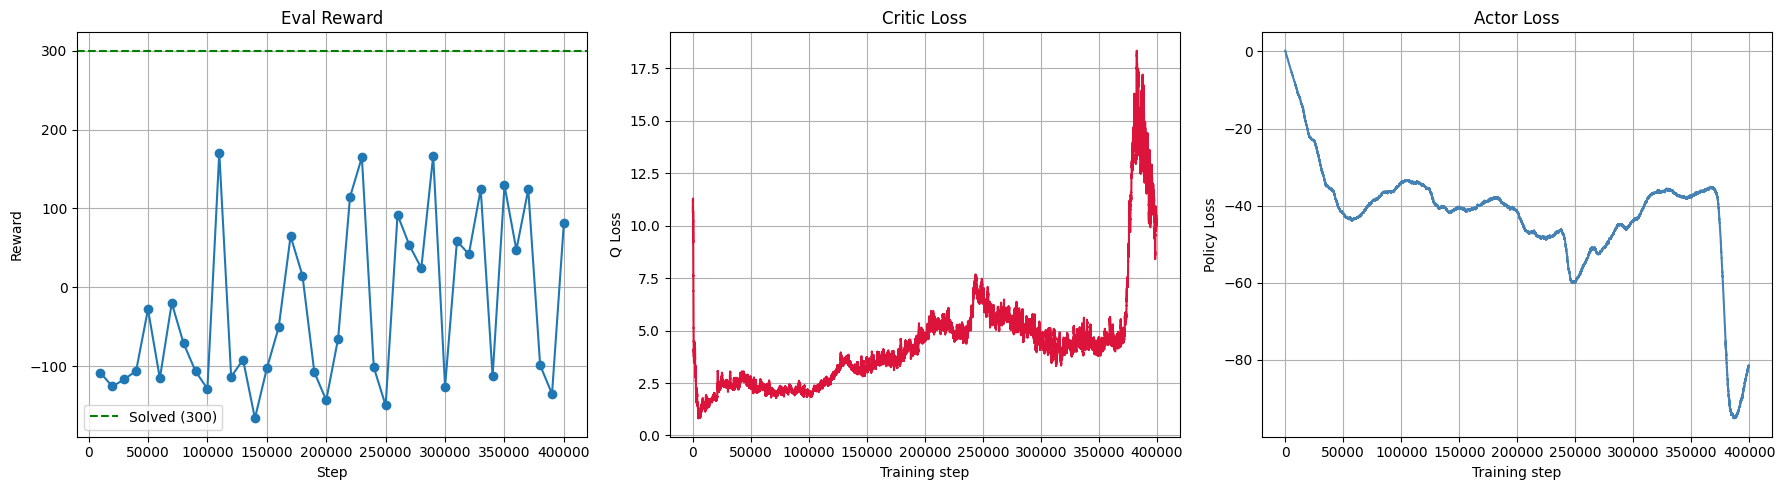

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Eval Reward
steps_x = np.arange(1, len(eval_rewards) + 1) * eval_freq
ax1.plot(steps_x, eval_rewards, marker='o')
ax1.axhline(y=100, color='g', linestyle='--', label="Solved (100)")
ax1.set_xlabel("Step")
ax1.set_ylabel("Reward")
ax1.set_title("Eval Reward")
ax1.legend()
ax1.grid(True)

# Critic Loss
window = 500
smoothed_q = np.convolve(train_q_losses, np.ones(window)/window, mode='valid')
ax2.plot(smoothed_q, color='crimson')
ax2.set_xlabel("Training step")
ax2.set_ylabel("Q Loss")
ax2.set_title("Critic Loss")
ax2.grid(True)

# Policy Loss
smoothed_p = np.convolve(train_p_losses, np.ones(window)/window, mode='valid')
ax3.plot(smoothed_p, color='steelblue')
ax3.set_xlabel("Training step")
ax3.set_ylabel("Policy Loss")
ax3.set_title("Actor Loss")
ax3.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
save_folder = '/content/drive/MyDrive/Colab Notebooks/RL/walker/'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
actor.save(save_folder + "actor.keras")
critic.save(save_folder + "critic.keras")
actor_target.save(save_folder + "actor_target.keras")
critic_target.save(save_folder + "critic_target.keras")

# Testing

In [ ]:
import imageio
import os
import matplotlib.pyplot as plt

def test_agent(actor, n_episodes=10, record_best=True, video_folder=save_folder):
    env = gym.make("BipedalWalker-v3", hardcore=False, render_mode='rgb_array')
    rewards = []
    best_reward = -float('inf')
    best_frames = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_reward = 0
        frames = []

        while not done:
            if record_best:
                frames.append(env.render())

            obs_input = np.expand_dims(obs, 0).astype(np.float32)
            with torch.no_grad():
                action = keras.ops.convert_to_numpy(actor(obs_input))[0]
            # Без шума — чистая политика

            obs, reward, term, trunc, _ = env.step(action)
            ep_reward += reward
            done = term or trunc

        rewards.append(ep_reward)
        print(f"  Episode {ep+1}: reward = {ep_reward:.1f}")

        if record_best and ep_reward > best_reward:
            best_reward = ep_reward
            best_frames = frames

    env.close()
    print(f"\nMean: {np.mean(rewards):.1f} | Min: {np.min(rewards):.1f} | Max: {np.max(rewards):.1f}")

    # Сохраняем видео лучшего эпизода
    if record_best and best_frames:
        os.makedirs(video_folder, exist_ok=True)
        path = os.path.join(video_folder, f"best_score_{int(best_reward)}.mp4")
        with imageio.get_writer(path, fps=30) as writer:
            for f in best_frames:
                writer.append_data(f)
        print(f"Video saved: {path}")

    # График
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, len(rewards) + 1), rewards)
    plt.axhline(y=np.mean(rewards), color='r', linestyle='--', label=f"Mean: {np.mean(rewards):.1f}")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Test Agent Performance")
    plt.xticks(range(1, len(rewards) + 1))
    plt.legend()
    plt.show()

    return rewards

  Episode 1: reward = 224.5
  Episode 2: reward = 223.7
  Episode 3: reward = 11.1
  Episode 4: reward = 236.6
  Episode 5: reward = -49.1
  Episode 6: reward = 213.2
  Episode 7: reward = 225.9
  Episode 8: reward = 208.5
  Episode 9: reward = 211.0


  Episode 10: reward = 32.4

Mean: 153.8 | Min: -49.1 | Max: 236.6
Video saved: /content/drive/MyDrive/Colab Notebooks/RL/walker/best_score_236.mp4


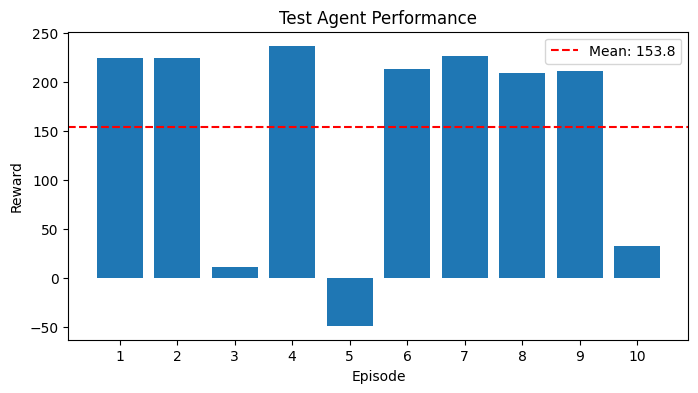

In [ ]:
test_rewards = test_agent(actor)


In [ ]:
from IPython.display import Video

In [ ]:
Video(save_folder + "best_score_236.mp4", embed=True)